<a href="https://colab.research.google.com/github/katiacardoso/Chapeu_Seletor_HarryPotter/blob/main/Dataframe_com_feiti%C3%A7o.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install lazypredict

## Importação de bibliotecas

In [ ]:
!pip install --upgrade scikit-learn

In [ ]:
from sklearn.tree import ExtraTreeClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import learning_curve

#para geração da árvore
from sklearn.tree import export_graphviz
import graphviz

#from sklearn.model_selection import GridSearchCV
from itertools import product
import pandas as pd
import numpy as np

#import lazypredict
#from lazypredict.Supervised import LazyClassifier

#para geração da visualização da matriz confusão
import seaborn as sns
import matplotlib.pyplot as plt




In [ ]:
#SHOW DO LAZY PREDICT QUERENDO FAZER GRAÇA

!find /usr/local/lib/python3.10/dist-packages -name "Supervised.py"
!sed -i 's/sparse=False/sparse_output=False/' /usr/local/lib/python3.10/dist-packages/lazypredict/Supervised.py
from lazypredict.Supervised import LazyClassifier

/usr/local/lib/python3.10/dist-packages/lazypredict/Supervised.py


/usr/local/lib/python3.10/dist-packages/dask/dataframe/__init__.py:42: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


## Verificação de versões utizadas

In [ ]:
import sklearn
import lazypredict
import seaborn
import matplotlib
import pandas as pd
import numpy as np


# Versão do scikit-learn
print("Versão do scikit-learn:", sklearn.__version__)

# Versão do lazypredict
print("Versão do lazypredict:", lazypredict.__version__)

# Versão do seaborn
print("Versão do seaborn:", seaborn.__version__)

# Versão do matplotlib
print("Versão do matplotlib:", matplotlib.__version__)

# Versão do pandas
print("Versão do pandas:", pd.__version__)

# Versão do numpy
print("Versão do numpy:", np.__version__)

# Versão do numpy
print("Versão do graphviz:", graphviz.__version__)

Versão do scikit-learn: 1.5.2
Versão do lazypredict: 0.2.12
Versão do seaborn: 0.13.1
Versão do matplotlib: 3.7.1
Versão do pandas: 2.2.2
Versão do numpy: 1.26.4
Versão do graphviz: 0.20.3


In [ ]:
notas = ['altas', 'medias', 'baixas']
interesses = ['magia', 'esportes', 'estudos', 'herbologia']
personalidades = ['ambicioso', 'inteligente', 'corajoso','leal','criativo']
casas = ['Grifinória', 'Lufa-Lufa', 'Corvinal', 'Sonserina']
ascendencias = ['puro', 'mestiço', 'nascidos_trouxa']
cor_cabelo = ['escuro', 'loiro', 'ruivo']
cor_olhos = ['azul', 'verde', 'castanho', 'preto']
feitico_favorito = ['nenhum', 'Accio', 'Alohomora', 'Avada Kedavra','Expelliarmus',
                    'Expecto Patronum', 'Lumos', 'Wingardium Leviosa', 'Protego',
                    'Imperio', 'Petrificus Totalus']



# Crie todas as combinações possíveis
combinacoes = list(product(notas, interesses, personalidades,ascendencias,cor_cabelo, cor_olhos, feitico_favorito ))

print("Exemplo de combinação:", combinacoes[2],"\n")
print("Quantidade de combinações: ", len(combinacoes))

Exemplo de combinação: ('altas', 'magia', 'ambicioso', 'puro', 'escuro', 'azul', 'Alohomora') 

Quantidade de combinações:  23760


In [ ]:
# Crie o DataFrame
df = pd.DataFrame(combinacoes, columns=['nota', 'interesse', 'personalidade', 'ascendencia', 'cor_cabelo', 'cor_olhos', 'feitico_favorito'])

# Adicione a coluna 'casa', atribuindo as casas de maneira rotativa
df['casa'] = [casas[i % len(casas)] for i in range(len(df))]

print(df.head())

    nota interesse personalidade ascendencia cor_cabelo cor_olhos  \
0  altas     magia     ambicioso        puro     escuro      azul   
1  altas     magia     ambicioso        puro     escuro      azul   
2  altas     magia     ambicioso        puro     escuro      azul   
3  altas     magia     ambicioso        puro     escuro      azul   
4  altas     magia     ambicioso        puro     escuro      azul   

  feitico_favorito        casa  
0           nenhum  Grifinória  
1            Accio   Lufa-Lufa  
2        Alohomora    Corvinal  
3    Avada Kedavra   Sonserina  
4     Expelliarmus  Grifinória  


In [ ]:
from prettytable import PrettyTable

# Criando uma tabela com as 5 primeiras linhas
table = PrettyTable(['Nota', 'Interesse', 'Personalidade', 'Ascendencia', 'Cor Cabelo', 'Cor Olhos', 'Casa', 'Feitiço Favorito'])
table.add_rows(df.head().values.tolist())
table.title = "Visualização 1 do Dataframe"
print(table)
df.shape

+-------------------------------------------------------------------------------------------------------------+
|                                         Visualização 1 do Dataframe                                         |
+-------+-----------+---------------+-------------+------------+-----------+---------------+------------------+
|  Nota | Interesse | Personalidade | Ascendencia | Cor Cabelo | Cor Olhos |      Casa     | Feitiço Favorito |
+-------+-----------+---------------+-------------+------------+-----------+---------------+------------------+
| altas |   magia   |   ambicioso   |     puro    |   escuro   |    azul   |     nenhum    |    Grifinória    |
| altas |   magia   |   ambicioso   |     puro    |   escuro   |    azul   |     Accio     |    Lufa-Lufa     |
| altas |   magia   |   ambicioso   |     puro    |   escuro   |    azul   |   Alohomora   |     Corvinal     |
| altas |   magia   |   ambicioso   |     puro    |   escuro   |    azul   | Avada Kedavra |    Sonserin

(23760, 8)

In [ ]:
# Embaralhe o DataFrame para que as combinações sejam distribuídas aleatoriamente entre as casas
df = df.sample(frac=1).reset_index(drop=True)

In [ ]:
# Criando uma tabela com as 5 primeiras linhas
table = PrettyTable(['Nota', 'Interesse', 'Personalidade', 'Ascendencia', 'Cor Cabelo', 'Cor Olhos', 'Casa', 'Feitiço Favorito'])
table.add_rows(df.head().values.tolist())
table.title = "Visualização 2 do Dataframe"
print(table)
df.shape

+-------------------------------------------------------------------------------------------------------------------+
|                                            Visualização 2 do Dataframe                                            |
+--------+------------+---------------+-----------------+------------+-----------+---------------+------------------+
|  Nota  | Interesse  | Personalidade |   Ascendencia   | Cor Cabelo | Cor Olhos |      Casa     | Feitiço Favorito |
+--------+------------+---------------+-----------------+------------+-----------+---------------+------------------+
| altas  |  esportes  |      leal     |     mestiço     |   escuro   |  castanho |    Imperio    |    Sonserina     |
| altas  |  estudos   |   ambicioso   |       puro      |   ruivo    |   verde   | Avada Kedavra |     Corvinal     |
| baixas |  esportes  |    corajoso   | nascidos_trouxa |   loiro    |    azul   | Avada Kedavra |    Sonserina     |
| altas  | herbologia |    criativo   |     mestiço     

(23760, 8)

In [ ]:

'''
# Defina regras para evitar certas combinações
regras = [
    (df['tipo_sanguineo'] == 'x') & (df['lealdade'] == 'Voldemort') & (df['casa'] == 'Lufa-Lufa')
]

# Aplicar as regras
for regra in regras:
    df = df[~regra]
'''

df.to_csv('dt.csv', index=False)

# Criar uma cópia do DataFrame
df_copia = df.copy()

# Salvar a cópia com um nome diferente
df_copia.to_csv('gb.csv', index=False)

#print(df, '\n')
#df.head()


# Crie um LabelEncoder
le = LabelEncoder().fit(['altas', 'medias', 'baixas',
                         'magia', 'esportes', 'estudos', 'herbologia',
                         'ambicioso', 'inteligente', 'corajoso','leal','criativo',
                         'Grifinória', 'Lufa-Lufa', 'Corvinal', 'Sonserina',
                         'puro', 'mestiço', 'nascidos_trouxa',
                         'escuro', 'castanho', 'loiro', 'ruivo',
                         'azul', 'verde', 'castanho','preto',
                         'nenhum', 'Accio', 'Alohomora', 'Avada Kedavra','Expelliarmus',
                         'Expecto Patronum', 'Lumos', 'Wingardium Leviosa', 'Protego',
                         'Imperio', 'Petrificus Totalus'])

# Transforme os dados usando o LabelEncoder
df['nota'] = le.transform(df['nota'])
df['interesse'] = le.transform(df['interesse'])
df['personalidade'] = le.transform(df['personalidade'])
df['casa'] = le.transform(df['casa'])
df['ascendencia'] = le.transform(df['ascendencia'])
df['cor_cabelo'] = le.transform(df['cor_cabelo'])
df['cor_olhos'] = le.transform(df['cor_olhos'])
df['feitico_favorito'] = le.transform(df['feitico_favorito'])



# Imprima os rótulos convertidos
print(df.head())

   nota  interesse  personalidade  ascendencia  cor_cabelo  cor_olhos  \
0    14         22             26           30          21         18   
1    14         23             15           34          35         36   
2    17         22             19           31          27         16   
3    14         24             20           30          27         33   
4    14         22             25           30          21         36   

   feitico_favorito  casa  
0                 7    12  
1                 2     3  
2                 2    12  
3                32     8  
4                 2     3  


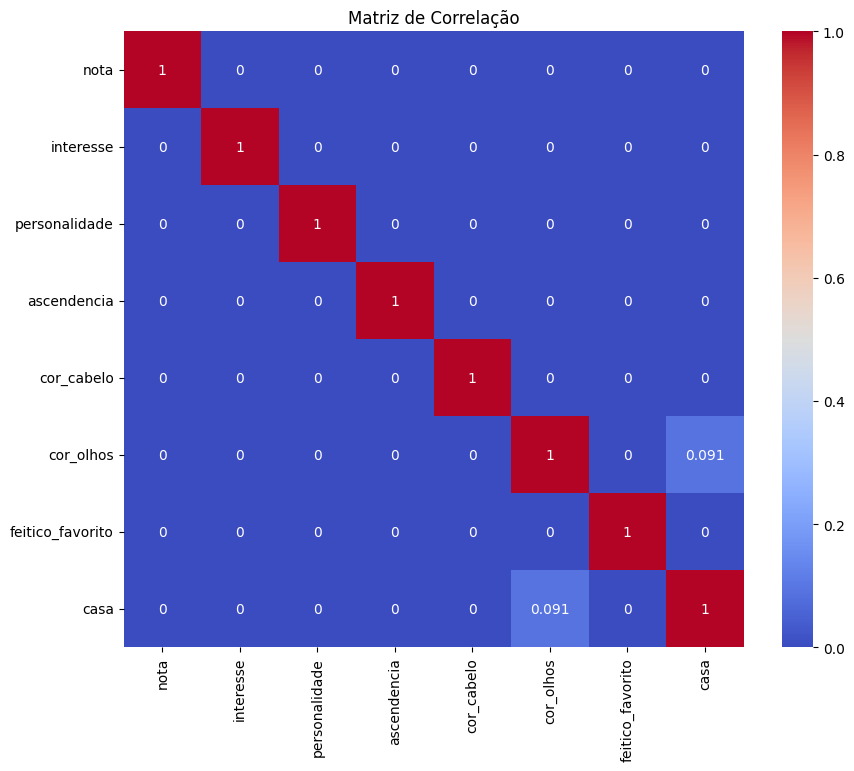

In [ ]:
# Calculando a matriz de correlação
corr_matrix = df.corr(method='spearman')

# Visualizando a matriz de correlação como um heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Matriz de Correlação')
plt.show()

In [ ]:
# Criando uma tabela com as 5 primeiras linhas
table = PrettyTable(['Nota', 'Interesse', 'Personalidade', 'Ascendencia', 'Cor Cabelo', 'Cor Olhos', 'Casa','Feitiço Favorito'])
table.add_rows(df.head().values.tolist())
table.title = "Visualização 3 do Dataframe"
print(table)
df.shape

+---------------------------------------------------------------------------------------------------+
|                                    Visualização 3 do Dataframe                                    |
+------+-----------+---------------+-------------+------------+-----------+------+------------------+
| Nota | Interesse | Personalidade | Ascendencia | Cor Cabelo | Cor Olhos | Casa | Feitiço Favorito |
+------+-----------+---------------+-------------+------------+-----------+------+------------------+
|  14  |     22    |       26      |      30     |     21     |     18    |  7   |        12        |
|  14  |     23    |       15      |      34     |     35     |     36    |  2   |        3         |
|  17  |     22    |       19      |      31     |     27     |     16    |  2   |        12        |
|  14  |     24    |       20      |      30     |     27     |     33    |  32  |        8         |
|  14  |     22    |       25      |      30     |     21     |     36    |  2   |

(23760, 8)

In [ ]:
# Obter os rótulos codificados
casas_codificados = le.transform(casas)

# Criar um DataFrame para mostrar a correspondência
mapping_df = pd.DataFrame({'Casa Original': casas, 'Código': casas_codificados})

#print(mapping_df)
# Criando a tabela PrettyTable
table = PrettyTable()
table.add_column("Casa Original", mapping_df['Casa Original'].tolist())
table.add_column("Código", mapping_df['Código'].tolist())
# Imprimindo a tabela
print(table)

+---------------+--------+
| Casa Original | Código |
+---------------+--------+
|   Grifinória  |   6    |
|   Lufa-Lufa   |   8    |
|    Corvinal   |   3    |
|   Sonserina   |   12   |
+---------------+--------+


In [ ]:
X = df[['nota', 'interesse', 'personalidade', 'ascendencia',  'cor_cabelo', 'cor_olhos', 'feitico_favorito']]
y = df['casa']


# Dividir os dados em treinamento e teste (70% treino, 30% teste)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=df['casa'])

# Dividir o conjunto de teste em teste e validação (20% teste, 10% validação)
X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=0.3, random_state=42, stratify=y_temp)

In [ ]:
# Criar DataFrames para cada conjunto
train_df = pd.DataFrame({'Conjunto': 'Treino', 'Classe': y_train})
test_df = pd.DataFrame({'Conjunto': 'Teste', 'Classe': y_test})
val_df = pd.DataFrame({'Conjunto': 'Validação', 'Classe': y_val})

# Concatenar os DataFrames para facilitar a criação da tabela
combined_df = pd.concat([train_df, test_df, val_df], ignore_index=True)

# Contar a frequência de cada classe em cada conjunto
counts = combined_df.groupby(['Conjunto', 'Classe']).size().reset_index(name='Contagem')

# Criar a tabela PrettyTable
table = PrettyTable()
table.field_names = ["Conjunto", "Classe", "Contagem"]
table.add_rows(counts.values.tolist())


# Imprimir a tabela
print(table)
df.shape

+-----------+--------+----------+
|  Conjunto | Classe | Contagem |
+-----------+--------+----------+
|   Teste   |   3    |   1247   |
|   Teste   |   6    |   1248   |
|   Teste   |   8    |   1247   |
|   Teste   |   12   |   1247   |
|   Treino  |   3    |   4158   |
|   Treino  |   6    |   4158   |
|   Treino  |   8    |   4158   |
|   Treino  |   12   |   4158   |
| Validação |   3    |   535    |
| Validação |   6    |   534    |
| Validação |   8    |   535    |
| Validação |   12   |   535    |
+-----------+--------+----------+


(23760, 8)

In [ ]:
print("Tamanho do conjunto de treinamento:", len(X_train))
print("Quantidade de variáveis no conjunto de treinamento:", X_train.shape[1])

print("Tamanho do conjunto de teste:", len(X_test))
print("Quantidade de variáveis no conjunto de teste:", X_test.shape[1])

print("Tamanho do conjunto de validação:", len(X_val))
print("Quantidade de variáveis no conjunto de validação:", X_val.shape[1])

Tamanho do conjunto de treinamento: 16632
Quantidade de variáveis no conjunto de treinamento: 7
Tamanho do conjunto de teste: 4989
Quantidade de variáveis no conjunto de teste: 7
Tamanho do conjunto de validação: 2139
Quantidade de variáveis no conjunto de validação: 7


In [ ]:
print(X_train.value_counts())
print(X_test.value_counts())
print(X_val.value_counts())

nota  interesse  personalidade  ascendencia  cor_cabelo  cor_olhos  feitico_favorito
14    22         15             30           21          16         0                   1
29    22         15             30           21          36         13                  1
                                                         16         0                   1
                                                                    1                   1
                                                                    4                   1
                                                                                       ..
17    22         15             30           21          16         5                   1
                                                                    7                   1
                                                                    11                  1
                                                                    13                  1
29    28       

In [ ]:
# Contando o número de dados de cada classe (altere para qual desejar)
contagem_de_classes = df["casa"].value_counts()

# Imprimindo o resultado
print(contagem_de_classes)

casa
12    5940
3     5940
8     5940
6     5940
Name: count, dtype: int64


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23760 entries, 0 to 23759
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   nota              23760 non-null  int64
 1   interesse         23760 non-null  int64
 2   personalidade     23760 non-null  int64
 3   ascendencia       23760 non-null  int64
 4   cor_cabelo        23760 non-null  int64
 5   cor_olhos         23760 non-null  int64
 6   feitico_favorito  23760 non-null  int64
 7   casa              23760 non-null  int64
dtypes: int64(8)
memory usage: 1.5 MB
None


## Lazy Predict

In [ ]:
# Dividir em conjuntos de treino e teste
#X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.3, random_state=42)


# Inicializar o LazyClassifier
clf = LazyClassifier()
modelos, pontuacoes = clf.fit(X_train, X_test, y_train, y_test)

# Exibir os modelos e suas pontuações
#print(modelos)
modelos
#print(pontuacoes)

 87%|████████▋ | 27/31 [03:18<00:42, 10.54s/it]

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001483 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 40
[LightGBM] [Info] Number of data points in the train set: 16632, number of used features: 7
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

100%|██████████| 31/31 [03:19<00:00,  6.42s/it]


,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Time Taken
Model,,,,,
LGBMClassifier,1.00,1.00,None,1.00,1.02
BaggingClassifier,1.00,1.00,None,1.00,0.22
DecisionTreeClassifier,1.00,1.00,None,1.00,0.08
RandomForestClassifier,0.97,0.97,None,0.97,1.61
ExtraTreesClassifier,0.96,0.96,None,0.96,5.14
ExtraTreeClassifier,0.59,0.59,None,0.59,0.10
NuSVC,0.48,0.48,None,0.48,120.69
SVC,0.39,0.39,None,0.39,30.25
QuadraticDiscriminantAnalysis,0.34,0.34,None,0.32,0.05


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Crie um modelo de Random Forest
model_random_forest = RandomForestClassifier()

# Treine o modelo
model_random_forest.fit(X_train, y_train)

# Faça previsões no conjunto de teste
y_pred_rf = model_random_forest.predict(X_test)

'''# Calcule a acurácia
acuracia_rf = accuracy_score(y_test, y_pred_rf)
print("Acurácia do Random Forest:", acuracia_rf, "\n")'''

# Calcule as métricas de avaliação
print("y_pred_rf: ", y_pred_rf)

unique_classes = np.unique(np.concatenate((y_test, y_pred_rf)))
relatorio = classification_report(y_test, y_pred_rf, target_names=le.inverse_transform(unique_classes))
print(relatorio)

y_pred_rf:  [12 12 12 ...  6  6  8]
              precision    recall  f1-score   support

    Corvinal       0.96      0.97      0.97      1247
  Grifinória       0.96      0.97      0.97      1248
   Lufa-Lufa       0.97      0.95      0.96      1247
   Sonserina       0.97      0.97      0.97      1247

    accuracy                           0.97      4989
   macro avg       0.97      0.97      0.97      4989
weighted avg       0.97      0.97      0.97      4989



In [ ]:
df['nota'] = le.inverse_transform(df['nota'])
df['interesse'] = le.inverse_transform(df['interesse'])
df['personalidade'] = le.inverse_transform(df['personalidade'])
df['casa'] = le.inverse_transform(df['casa'])
df['ascendencia'] = le.inverse_transform(df['ascendencia'])
df['cor_cabelo'] = le.inverse_transform(df['cor_cabelo'])
df['cor_olhos'] = le.inverse_transform(df['cor_olhos'])
df['feitico_favorito'] = le.inverse_transform(df['feitico_favorito'])


print("Classes Previstas:", y_pred_rf)
print("Classes Verdadeiras:\n", y_test)


# Agora você pode visualizar os dados de treinamento e teste com os rótulos originais
print("Dados de treinamento:")
print(X_train)
print(y_train)

print("\nDados de teste:")
print(X_test)
print(y_test)

Classes Previstas: [12 12 12 ...  6  6  8]
Classes Verdadeiras:
 22269    12
13621    12
10026    12
10897     8
5306      6
         ..
23160     8
16875     8
18963     6
9540      6
15124     8
Name: casa, Length: 4989, dtype: int64
Dados de treinamento:
       nota  interesse  personalidade  ascendencia  cor_cabelo  cor_olhos  \
2778     14         23             19           30          21         36   
4547     14         23             19           34          35         16   
7527     17         28             20           30          35         16   
6904     17         22             26           34          21         16   
8608     14         28             25           34          27         33   
...     ...        ...            ...          ...         ...        ...   
11202    14         23             19           34          27         33   
8614     29         24             26           31          21         36   
22792    14         22             26           3

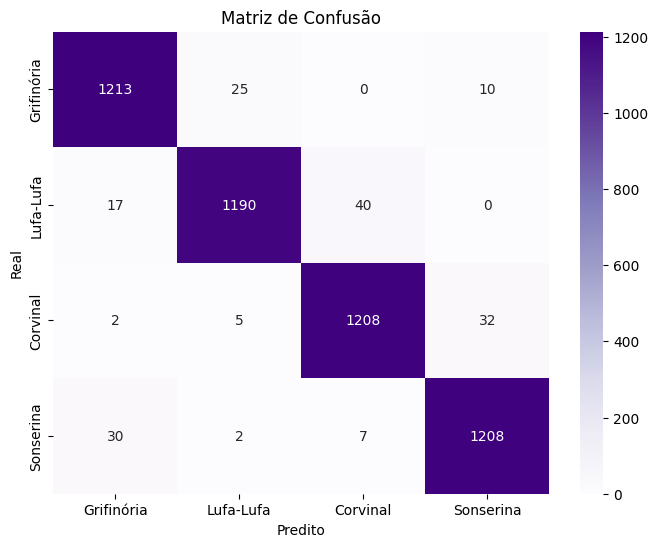

              precision    recall  f1-score   support

  Grifinória       0.96      0.97      0.97      1247
   Lufa-Lufa       0.96      0.97      0.97      1248
    Corvinal       0.97      0.95      0.96      1247
   Sonserina       0.97      0.97      0.97      1247

    accuracy                           0.97      4989
   macro avg       0.97      0.97      0.97      4989
weighted avg       0.97      0.97      0.97      4989



In [ ]:
# Mapeando os valores preditos de volta para os rótulos das classes
class_labels = ['Grifinória', 'Lufa-Lufa', 'Corvinal', 'Sonserina']

# Inverter a transformação do Label Encoder
y_pred_originais = le.inverse_transform(y_pred_rf)
y_test = le.inverse_transform(y_test)

# Converter ambos y_test e y_pred_originais para o mesmo tipo de dados (neste caso, string)
y_test_str = y_test.astype(str)
y_pred_str = y_pred_originais.astype(str)

# Verificando se todas as classes em class_labels estão presentes em y_test_str
for label in class_labels:
    if label not in y_test_str:
        print(f"A classe {label} não está presente nos rótulos reais.")
        # Trate essa situação, talvez removendo a classe ausente de class_labels ou tomando outra ação apropriada.


# Criando a matriz de confusão
conf_matrix = confusion_matrix(y_test_str, y_pred_str, labels=class_labels)

# Plotando a matriz de confusão
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Purples", xticklabels=class_labels, yticklabels=class_labels)
plt.title("Matriz de Confusão")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.show()

# Imprimindo relatórios de classificação
print(classification_report(y_test_str, y_pred_str, target_names=class_labels))

In [ ]:
from sklearn.tree import export_graphviz, plot_tree
import graphviz

# 1. Visualização de uma árvore individual do Random Forest
def visualize_tree(model, tree_index, filename):
    """
    Visualiza uma árvore de decisão do modelo Random Forest.

    Args:
        model: Modelo Random Forest.
        tree_index: Índice da árvore a ser visualizada.
        filename: Nome do arquivo para salvar a imagem.
    """

    # Aumentar o tamanho da figura e a fonte
    plt.figure(figsize=(50, 30))
    plot_tree(model.estimators_[tree_index],
              feature_names=X.columns,
              class_names=['Grifinória', 'Lufa-Lufa', 'Corvinal', 'Sonserina'],
              filled=True,
              rounded=True,
              fontsize=16,
              max_depth=7)  # Limitar a profundidade da árvore para melhor visualização

    # Ajustar a resolução e o recorte da imagem
    plt.title(f"Árvore {tree_index} da Floresta Aleatória", fontsize=24)
    plt.savefig(f'{filename}.png', dpi=600, bbox_inches='tight')
    plt.close()

# Exemplo de uso
visualize_tree(model_random_forest, 0, "random_forest_tree_0")
visualize_tree(model_random_forest, 1, "random_forest_tree_1")
visualize_tree(model_random_forest, 2, "random_forest_tree_2")

# 2. Importância das características
plt.figure(figsize=(12,8))
importances = model_random_forest.feature_importances_
indices = np.argsort(importances)[::-1]
plt.title("Feature Importances in Random Forest", fontsize=16)
plt.bar(range(X.shape[1]), importances[indices])
plt.xticks(range(X.shape[1]), [f'Feature {i}' for i in indices], rotation=45)
plt.xlabel("Features", fontsize=12)
plt.ylabel("Importance", fontsize=12)
plt.tight_layout()
plt.savefig('random_forest_feature_importance.png', dpi=300, bbox_inches='tight')
plt.close()

# 5. Visualização da profundidade das árvores
tree_depths = [estimator.get_depth() for estimator in model_random_forest.estimators_]
plt.figure(figsize=(10,6))
plt.hist(tree_depths, bins=20)
plt.title('Distribution of Tree Depths in Random Forest', fontsize=16)
plt.xlabel('Tree Depth', fontsize=12)
plt.ylabel('Number of Trees', fontsize=12)
plt.savefig('random_forest_tree_depths.png', dpi=300, bbox_inches='tight')
plt.close()

In [ ]:
'''from sklearn.tree import export_graphviz
import graphviz

# Número de árvores no modelo Random Forest
n_trees = len(model_random_forest.estimators_)

# Gerar uma visualização para cada árvore individual
for i in range(n_trees):
    estimator = model_random_forest.estimators_[i]

    # Exportar a árvore de decisão para o formato Graphviz com mais opções para melhorar a visualização
    dot_data = export_graphviz(estimator, out_file=None,
                               feature_names=X.columns,  # Usar os nomes das colunas como nomes de recursos
                               class_names=['Grifinória', 'Lufa-Lufa', 'Corvinal', 'Sonserina'],  # Especifique os nomes das classes
                               filled=True,
                               rounded=True,
                               node_ids=True,
                               impurity=True,
                               precision=2,
                               max_depth=5)  # Limitar a profundidade da árvore (pode ser ajustado)

    # Use o Graphviz para gerar um gráfico da árvore de decisão
    graph = graphviz.Source(dot_data)

    # Salvar a imagem da árvore
    filename = f"tree_{i}"
    graph.render(filename, format="png", cleanup=True)

    # Se quiser visualizar cada árvore no notebook, use:
    # graph.view()
'''

'from sklearn.tree import export_graphviz\nimport graphviz\n\n# Número de árvores no modelo Random Forest\nn_trees = len(model_random_forest.estimators_)\n\n# Gerar uma visualização para cada árvore individual\nfor i in range(n_trees):\n    estimator = model_random_forest.estimators_[i]\n\n    # Exportar a árvore de decisão para o formato Graphviz com mais opções para melhorar a visualização\n    dot_data = export_graphviz(estimator, out_file=None,\n                               feature_names=X.columns,  # Usar os nomes das colunas como nomes de recursos\n                               class_names=[\'Grifinória\', \'Lufa-Lufa\', \'Corvinal\', \'Sonserina\'],  # Especifique os nomes das classes\n                               filled=True,\n                               rounded=True,\n                               node_ids=True,\n                               impurity=True,\n                               precision=2,\n                               max_depth=5)  # Limitar a profundi

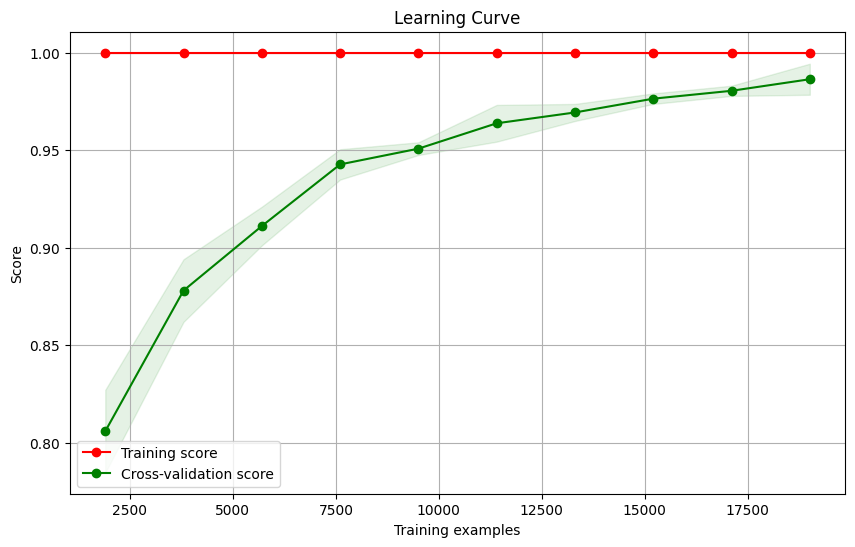

In [ ]:
# Função para plotar a curva de aprendizado
def plot_learning_curve(estimator, X, y, cv=None, train_sizes=np.linspace(0.1, 1.0, 10)):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, train_sizes=train_sizes, scoring='accuracy', n_jobs=-1)

    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    plt.figure(figsize=(10, 6))
    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score")
    plt.xlabel("Training examples")
    plt.ylabel("Score")
    plt.title("Learning Curve")
    plt.legend(loc="best")
    plt.grid(True)
    plt.show()

# Plote a curva de aprendizado para o seu modelo
plot_learning_curve(model_random_forest, X, y, cv=5)

In [ ]:
# Obter a importância das características
importancias_caracteristicas = model_random_forest.feature_importances_

# Mostrar a importância das características
for i, importancia in enumerate(importancias_caracteristicas):
    print(f'Característica {X.columns[i]}: {importancia}')

# Verificar se há alguma característica com grande importância
importancia_maxima = max(importancias_caracteristicas)
print("\nA maior importância encontrada:", importancia_maxima)

# Calcular a média da importância das características
importancia_media = np.mean(importancias_caracteristicas)
print("\nA média da importância das características:", importancia_media)

Característica nota: 0.021459551630371797
Característica interesse: 0.02902952705388983
Característica personalidade: 0.03781584737391227
Característica ascendencia: 0.020595629402008302
Característica cor_cabelo: 0.01921437455503137
Característica cor_olhos: 0.2282155262710998
Característica feitico_favorito: 0.6436695437136867

A maior importância encontrada: 0.6436695437136867

A média da importância das características: 0.14285714285714285


In [ ]:
# Fazer previsões nos dados de validação
predicoes_validacao =  model_random_forest.predict(X_val)

# Avaliar o desempenho do modelo nos dados de validação
print("Acurácia:", accuracy_score(y_val, predicoes_validacao))
print("Precisão:", precision_score(y_val, predicoes_validacao, average='weighted'))
print("Recall:", recall_score(y_val, predicoes_validacao, average='weighted'))
print("F1-score:", f1_score(y_val, predicoes_validacao, average='weighted'))

Acurácia: 0.9630668536699393
Precisão: 0.9630982143829291
Recall: 0.9630668536699393
F1-score: 0.9630706783967136


## Novo aluno

Necessita de ajustes para realizar a entrada com dados de validação para conseguir tirar métricas e visualizar a casa prevista e a casa real.

Contudo ainda segue sendo importante ter uma implementação de entrada de características de um novo aluno já que a ideia é ter um chapeu seletor

notas = ['altas', 'medias', 'baixas']

interesses = ['magia', 'esportes', 'estudos', 'herbologia']

personalidades = ['ambicioso', 'inteligente', 'corajoso','leal','criativo']

casas = ['Grifinória', 'Lufa-Lufa', 'Corvinal', 'Sonserina']

ascendencias = ['puro', 'mestiço', 'nascidos_trouxa']

cor_cabelo = ['escuro', 'loiro', 'ruivo']

cor_olhos = ['azul', 'verde', 'castanho', 'preto']

In [ ]:
# Características do novo aluno
novo_aluno_array = np.array(['altas', 'magia', 'ambicioso', 'puro', 'escuro', 'azul', 'nenhum'])

# Transformação dos dados usando o LabelEncoder
novo_aluno_encoded = le.transform(novo_aluno_array)

# Previsão usando o modelo treinado
predicao = model_random_forest.predict([novo_aluno_encoded])

# Avaliar o desempenho do modelo nos dados de validação
print("Acurácia:", accuracy_score(y_val, predicoes_validacao))
print("Precisão:", precision_score(y_val, predicoes_validacao, average='weighted'))
print("Recall:", recall_score(y_val, predicoes_validacao, average='weighted'))
print("F1-score:", f1_score(y_val, predicoes_validacao, average='weighted'))

# Mapeamento do resultado de volta para a classe original usando o LabelEncoder inverso
casa_predita = le.inverse_transform(predicao)[0]

print(f'\nO novo aluno provavelmente pertence à casa: {casa_predita} \n')

# Obter a probabilidade de pertencer a cada classe
probabilidades = model_random_forest.predict_proba([novo_aluno_encoded])

# Mapeamento das probabilidades de volta para as classes originais usando o LabelEncoder inverso
classes = le.inverse_transform(model_random_forest.classes_)

# Impressão das probabilidades para cada classe
for classe, probabilidade in zip(classes, probabilidades[0]):
    print(f'Probabilidade de pertencer à casa {classe}: {probabilidade:.2f}')

Acurácia: 0.9630668536699393
Precisão: 0.9630982143829291
Recall: 0.9630668536699393
F1-score: 0.9630706783967136

O novo aluno provavelmente pertence à casa: Grifinória 

Probabilidade de pertencer à casa Corvinal: 0.01
Probabilidade de pertencer à casa Grifinória: 0.90
Probabilidade de pertencer à casa Lufa-Lufa: 0.01
Probabilidade de pertencer à casa Sonserina: 0.08
